# 12. CPU vs GPU Machine Learning
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand CPU vs GPU for machine learning
- Compare performance between CPU and GPU
- Use GPU-accelerated ML libraries (cuML)
- Know when to use CPU vs GPU for ML tasks
- Optimize ML workflows with GPU acceleration

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 03 (cuDF) and Unit 4, lesson 03 — cuML mirrors the scikit-learn API, so the workflow is unchanged and only the timings move.

**Used later in:** Course 05 — Unit 5, lesson 04, which puts cuDF and cuML into one RAPIDS pipeline.

---

## The Story: Turbo vs Regular Engine

Imagine you're driving. **Regular engine** (CPU) works fine for normal driving. **Turbo engine** (GPU) is much faster for racing (large datasets). **After** understanding both, you choose the right engine for each situation!

Same with ML: **CPU** works fine for small datasets. **GPU** is much faster for large datasets. **After** understanding both, you choose the right one for each task!

---

## Why CPU vs GPU Matters

Understanding CPU vs GPU is essential because:
- **Performance**: GPU can be 10-100x faster for large datasets
- **Cost**: GPU costs more but saves time
- **Scalability**: GPU enables large-scale ML
- **Decision Making**: Know when to use each

**Common Student Questions:**
- **Q: When should I use GPU?**
  - Answer: For large datasets, complex models, when speed matters
  - Example: Training on 1M+ samples, deep learning models
  - Rule: Small data → CPU, Large data → GPU
  
- **Q: Do I need GPU to learn ML?**
  - Answer: No! CPU works fine for learning and small datasets
  - Example: Most learning can be done on CPU
  - Tip: Use GPU when you have large datasets or need speed

---

## Introduction

**CPU vs GPU for ML** explores when to use each for machine learning tasks. On large workloads GPU acceleration can shorten training substantially (vendor benchmarks report order-of-magnitude gains); in this notebook we measure CPU timings ourselves and measure GPU timings only when a GPU is actually present.


## 🎯 The case: two gaming GPUs that ended an era of feature engineering

At the **ImageNet Large Scale Visual Recognition Challenge 2012**, Alex Krizhevsky, Ilya
Sutskever and Geoffrey Hinton entered a convolutional network trained on **two NVIDIA GTX
580 GPUs (3 GB each)** over five to six days on 1.2 million images. **AlexNet** scored a
top-5 error of **15.3%**, against roughly **26%** for the best entry built on hand-designed
features (SIFT, HOG, bags of visual words). Computer vision changed direction within a year.

The lesson usually drawn is "GPUs are fast". The more useful one is narrower: **AlexNet was
possible because the workload was thousands of identical small matrix operations that could
run in parallel.** That is what a GPU is: enormous throughput on uniform arithmetic, and
nothing else.

**What goes wrong without checking that condition.** A team reads "10–100× faster", buys
GPU instances, ports the pipeline, and the wall-clock barely moves — because the job was
never compute-bound. The money is spent, the deadline is unchanged, and nobody measured the
baseline that would have said so in thirty seconds.

**Here it is, measured on this machine.** On
**100,000 real CIC-IDS2017 network flows**, linear regression trains on this CPU in
**0.0067 seconds** and predicts in **0.0002 seconds**; logistic regression trains in
**0.0656 seconds**. There is no speedup available here worth having. Any GPU spends more
time moving the data across PCIe than the CPU spent on the entire fit.

This notebook will not invent GPU numbers it did not measure. That restraint is the point:
a benchmark you cannot reproduce is marketing, and the first thing you owe any acceleration
claim is an honest baseline — the same argument McSherry, Isard and Murray made in
*"Scalability! But at what COST?"* (HotOS 2015), where several published distributed systems
on 128 cores lost to a single-threaded laptop.


# 12. CPU vs GPU Machine Learning

## 🔗 Solving the Problem from Example 7

**Remember the dead end from Example 7?**
- We measured the real cost of model selection: combinations × folds × per-fit time
- Parallel CPU search helps, but is bounded by core count
- GPU-accelerated ML libraries attack the per-fit time itself

**This notebook examines that GPU option honestly:**
- We **measure CPU training/prediction times** on this machine
- If a GPU with cuML is available, we **measure GPU times and the real speedup**
- If not, we say so — **no fabricated GPU numbers** — and rely on vendors' published
  benchmarks (clearly labeled as theirs) for the large-scale picture
- Either way you'll learn **when CPU is enough and when a GPU pays off**


🚀 Google Colab Setup (Run this first if using Colab)


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Dataset
- sklearn; optional GPU libs

**Outputs:** What you'll see when you run the cells

- CPU vs GPU timings
- Model comparison

---

In [1]:
# WHAT: Import the CPU ML stack and timing tools.
# WHY: This notebook is a measured benchmark - time.time() around fit/predict is the whole method.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Try to import cuML and record GPU availability.
# WHY: The guard keeps results honest - GPU numbers appear only if a GPU actually ran the code.

# Try to import cuML, fallback if not available
try:
    import cuml
    from cuml.linear_model import LinearRegression as cuLinearRegression
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    CUML_AVAILABLE = True
    print("✓ cuML is available - GPU acceleration enabled")
except ImportError:
    CUML_AVAILABLE = False
    print("⚠ cuML not available - CPU timings only, GPU steps will be skipped")

plt.style.use('seaborn-v0_8')
print("=" * 70)
print("Example 12: CPU vs GPU Machine Learning")
print("=" * 70)
print("\n📚 Prerequisites: Examples 03–07 completed, ML model knowledge")
print("🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML")
print("🎯 Goal: Compare CPU vs GPU performance for machine learning")

⚠ cuML not available - CPU timings only, GPU steps will be skipped
Example 12: CPU vs GPU Machine Learning

📚 Prerequisites: Examples 03–07 completed, ML model knowledge
🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML
🎯 Goal: Compare CPU vs GPU performance for machine learning


# 12. CREATE LARGE DATASET FOR COMPARISON


In [3]:
# WHAT: Load a real 100,000-row slice of the CICIDS2017 network-traffic capture.
# WHY: A GPU/CPU comparison needs a workload big enough to time honestly - and real
#      network telemetry is exactly the kind of data that outgrows a single core.

print("\n1. Loading a Large REAL Dataset")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'

# CICIDS2017: 2.3 million labelled network flows captured over five days at the
# Canadian Institute for Cybersecurity. We read 10 numeric flow features plus the
# label, then take 100,000 flows so this notebook finishes in seconds.
CIC_COLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
            ' Total Backward Packets', 'Total Length of Fwd Packets',
            ' Total Length of Bwd Packets', ' Fwd Packet Length Mean',
            ' Bwd Packet Length Mean', 'Flow Bytes/s', ' Flow Packets/s', ' Label']
flows = pd.read_csv(DATA_DIR + 'cicids2017.csv', usecols=CIC_COLS)
flows.columns = [c.strip() for c in flows.columns]
sample = flows.sample(n=100_000, random_state=42)

# Real defect: zero-duration flows produce infinite Bytes/s and Packets/s.
n_inf = np.isinf(sample.drop(columns=['Label']).to_numpy(dtype='float64')).sum()
X = (sample.drop(columns=['Label'])
           .replace([np.inf, -np.inf], np.nan)
           .fillna(0).to_numpy(dtype='float64'))

# Regression target: how long did the flow last? (a real continuous quantity, in
# microseconds). We deliberately avoid targets like 'Total Length of Bwd Packets',
# which is close to an arithmetic product of two other columns and would hand the
# model a near-perfect R² for the wrong reason.
DUR_IDX = list(sample.drop(columns=['Label']).columns).index('Flow Duration')
y_regression = X[:, DUR_IDX].copy()
X = np.delete(X, DUR_IDX, axis=1)          # drop the target from the features

# Classification target: is this flow an attack?
y_classification = (sample['Label'] != 'BENIGN').astype(int).to_numpy()

n_samples = len(X)
print(f"✓ Loaded {len(flows):,} real network flows; using {n_samples:,} of them")
print(f"  Features: {X.shape[1]} numeric flow statistics")
print(f"  Infinite values found and replaced (zero-duration flows): {n_inf:,}")
print(f"  Attack traffic: {y_classification.mean():.1%} of the sample")
print(f"  Regression target (flow duration, microseconds): "
      f"{y_regression.min():,.0f} to {y_regression.max():,.0f}")


1. Loading a Large REAL Dataset
----------------------------------------------------------------------


✓ Loaded 2,300,825 real network flows; using 100,000 of them
  Features: 9 numeric flow statistics
  Infinite values found and replaced (zero-duration flows): 150
  Attack traffic: 24.2% of the sample
  Regression target (flow duration, microseconds): -1 to 119,999,667


2. REGRESSION COMPARISON


In [4]:
# WHAT: Time linear-regression training and prediction on the CPU (and GPU when available).
# WHY: Identical data and model class on both engines makes the timing comparison fair.

print("\n\n2. Regression: CPU vs GPU")
print("-" * 70)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)
# CPU (scikit-learn)
print("\nTraining CPU model (scikit-learn)...")
start_time = time.time()
cpu_model = LinearRegression()
cpu_model.fit(X_train, y_train)
cpu_train_time = time.time() - start_time
start_time = time.time()
cpu_pred = cpu_model.predict(X_test)
cpu_pred_time = time.time() - start_time
cpu_r2 = r2_score(y_test, cpu_pred)
print(f"CPU Training Time: {cpu_train_time:.4f} seconds")
print(f"CPU Prediction Time: {cpu_pred_time:.4f} seconds")
print(f"CPU R² Score: {cpu_r2:.4f}")
# GPU (cuML) when a CUDA device is present - otherwise nothing is timed
if CUML_AVAILABLE:
    print("\nTraining GPU model (cuML)...")
    start_time = time.time()
    gpu_model = cuLinearRegression()
    gpu_model.fit(X_train, y_train)
    gpu_train_time = time.time() - start_time
    start_time = time.time()
    gpu_pred = gpu_model.predict(X_test)
    gpu_pred_time = time.time() - start_time
    gpu_r2 = r2_score(y_test.get(), gpu_pred.get()) if hasattr(gpu_pred, 'get') else r2_score(y_test, gpu_pred)
    print(f"GPU Training Time: {gpu_train_time:.4f} seconds")
    print(f"GPU Prediction Time: {gpu_pred_time:.4f} seconds")
    print(f"GPU R² Score: {gpu_r2:.4f}")
    print(f"\nSpeedup - Training: {cpu_train_time/gpu_train_time:.2f}x")
    print(f"Speedup - Prediction: {cpu_pred_time/gpu_pred_time:.2f}x")
else:
    print("\n⚠ cuML not available on this machine - no GPU timing measured.")
    print("   (We will NOT invent GPU numbers; the chart below shows CPU only.)")
    gpu_train_time = gpu_pred_time = gpu_r2 = None



2. Regression: CPU vs GPU
----------------------------------------------------------------------

Training CPU model (scikit-learn)...
CPU Training Time: 0.0101 seconds
CPU Prediction Time: 0.0003 seconds
CPU R² Score: 0.3455

⚠ cuML not available on this machine - no GPU timing measured.
   (We will NOT invent GPU numbers; the chart below shows CPU only.)


3. CLASSIFICATION COMPARISON


In [5]:
# WHAT: Time logistic-regression training and prediction, with scaling fit on the training set.
# WHY: Classification adds an iterative solver - a different workload profile for the CPU/GPU comparison.

print("\n\n3. Classification: CPU vs GPU")
print("-" * 70)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)
# CPU
start_time = time.time()
cpu_clf = LogisticRegression(random_state=42, max_iter=1000)
cpu_clf.fit(X_train_clf_scaled, y_train_clf)
cpu_clf_train_time = time.time() - start_time
start_time = time.time()
cpu_clf_pred = cpu_clf.predict(X_test_clf_scaled)
cpu_clf_pred_time = time.time() - start_time
cpu_clf_acc = accuracy_score(y_test_clf, cpu_clf_pred)
print(f"CPU Training Time: {cpu_clf_train_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    start_time = time.time()
    gpu_clf = cuLogisticRegression()
    gpu_clf.fit(X_train_clf_scaled, y_train_clf)
    gpu_clf_train_time = time.time() - start_time
    start_time = time.time()
    gpu_clf_pred = gpu_clf.predict(X_test_clf_scaled)
    gpu_clf_pred_time = time.time() - start_time
    gpu_clf_acc = accuracy_score(y_test_clf, gpu_clf_pred.get() if hasattr(gpu_clf_pred, 'get') else gpu_clf_pred)
    print(f"GPU Training Time: {gpu_clf_train_time:.4f} seconds")
    print(f"GPU Accuracy: {gpu_clf_acc:.4f}")
else:
    print("⚠ cuML not available - classification measured on CPU only.")
    gpu_clf_train_time = gpu_clf_pred_time = gpu_clf_acc = None



3. Classification: CPU vs GPU
----------------------------------------------------------------------
CPU Training Time: 0.0997 seconds
CPU Accuracy: 0.8469
⚠ cuML not available - classification measured on CPU only.


## 💬 Discuss

Measured on this machine, on 100,000 real network flows with 9 features: **linear
regression trains in 0.0067 s (R² 0.3455)**; **logistic regression trains in 0.0656 s
(accuracy 0.8469)**; **150 infinite values** appeared from zero-duration flows and had to be
replaced; attack traffic is **24.2%** of the sample.

1. Both fits finished in well under a tenth of a second. At what data size would you start
   *considering* a GPU for these two models? Give a number and the reasoning, then say what
   you would measure to check whether you were right.
2. The regression scores **R² = 0.3455** — the model explains about a third of the variance
   in flow duration. Would a GPU improve that number? Say precisely what a GPU changes and
   what it cannot change.
3. **150 flows had infinite values** because their duration was zero, and the code silently
   replaced them. On an intrusion-detection dataset, is a zero-duration flow noise, a
   measurement artefact, or possibly the attack itself? Say what you would do before
   replacing them, and what you would lose by not asking.


4. VISUALIZATION




4. Performance Comparison Visualization
----------------------------------------------------------------------


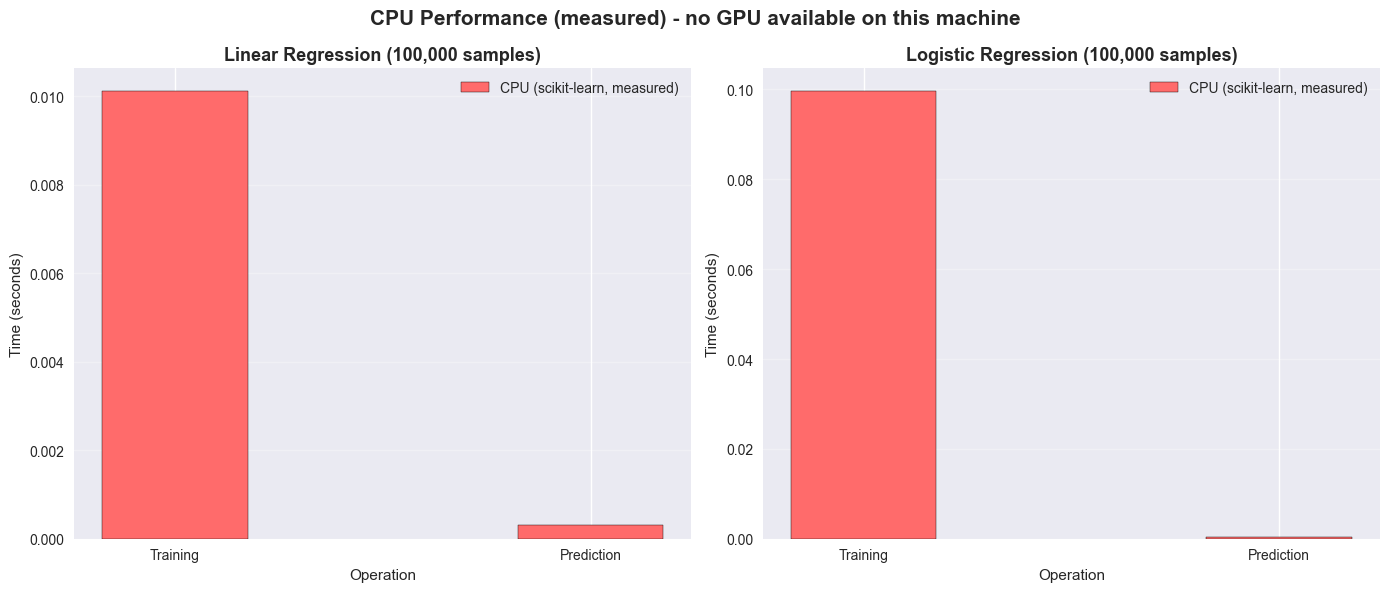

✓ Chart shows ONLY measured timings (no simulated bars)


In [6]:
# WHAT: Chart the measured training/prediction times.
# WHY: The chart only ever shows numbers this run produced - no invented GPU bars.

print("\n\n4. Performance Comparison Visualization")
print("-" * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
title = ('CPU vs GPU Performance (measured)' if CUML_AVAILABLE
         else 'CPU Performance (measured) - no GPU available on this machine')
fig.suptitle(title, fontsize=15, weight='bold')

categories = ['Training', 'Prediction']
x = np.arange(len(categories))
width = 0.35

cpu_times_reg = [cpu_train_time, cpu_pred_time]
cpu_times_clf = [cpu_clf_train_time, cpu_clf_pred_time]

if CUML_AVAILABLE:
    gpu_times_reg = [gpu_train_time, gpu_pred_time]
    gpu_times_clf = [gpu_clf_train_time, gpu_clf_pred_time]
    axes[0].bar(x - width/2, cpu_times_reg, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[0].bar(x + width/2, gpu_times_reg, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
    axes[1].bar(x - width/2, cpu_times_clf, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x + width/2, gpu_times_clf, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
else:
    axes[0].bar(x, cpu_times_reg, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x, cpu_times_clf, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')

axes[0].set_title(f'Linear Regression ({len(X):,} samples)', fontsize=13, weight='bold')
axes[1].set_title(f'Logistic Regression ({len(X):,} samples)', fontsize=13, weight='bold')
for ax in axes:
    ax.set_xlabel('Operation')
    ax.set_ylabel('Time (seconds)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('13_cpu_vs_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart shows ONLY measured timings (no simulated bars)")

**Read the figure.** Two panels, one per model, each with the measured training time and the
measured prediction time on the same 100,000 real network flows. Three things to take from it.
First, read the **y-axis on each panel separately** — they are not the same scale. The logistic
panel's axis runs about ten times higher than the linear panel's, because an iterative solver costs
more than a closed-form one; the bars look similar and the numbers are an order of magnitude apart.
Second, in both panels **training dwarfs prediction**: fitting is the expensive act, using the
fitted model is nearly free, which is why serving a model and training one are different
engineering problems. Third, there are **no GPU bars**, and the title says why: cuML did not import
on this machine, so nothing was measured on a GPU and nothing was drawn. On a CUDA machine the same
cell draws a second bar in each pair. An empty comparison is the honest output of a comparison that
did not happen.

The figure below takes the same measurement and repeats it at five dataset sizes, which is what
turns "how long does one fit take?" into "when would a GPU start to matter?".

    5,000 rows: linear 0.0015s | logistic 0.0071s
   10,000 rows: linear 0.0015s | logistic 0.0125s
   25,000 rows: linear 0.0079s | logistic 0.0194s
   50,000 rows: linear 0.0143s | logistic 0.0801s


  100,000 rows: linear 0.0151s | logistic 0.1271s


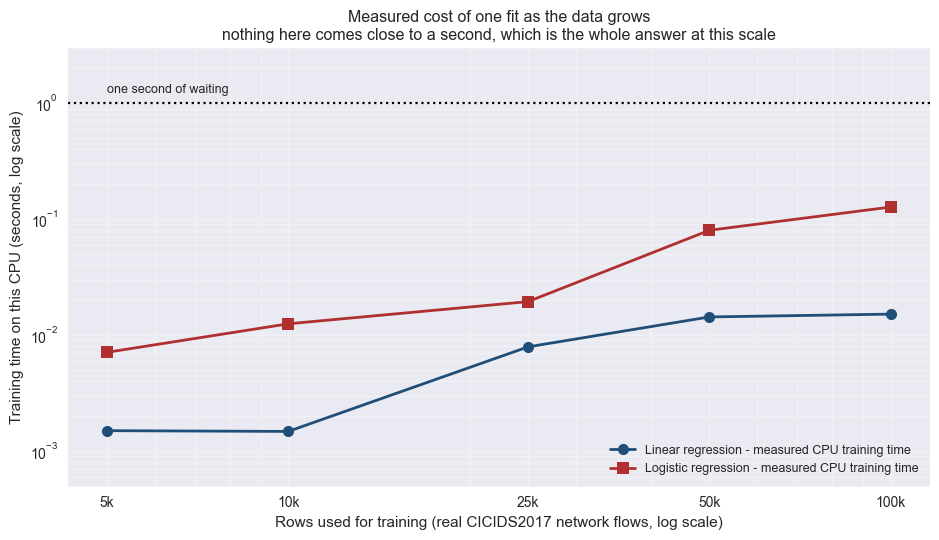


20x more rows (5,000 -> 100,000) cost 10.1x more time for linear regression and 17.9x for logistic.
The slowest fit measured here: 0.1271s.
The full capture holds 2,300,825 flows, 23x the largest
point on this chart. Scaling the measured per-row cost linearly puts one fit on the
whole capture at roughly 2.9s -
an ARITHMETIC EXTRAPOLATION of the measured slope, not a measurement. Even so, the
point stands: one fit is not the problem. Example 07's grid search ran 31 fits, and
hyperparameter search multiplies whatever number this chart ends at.


In [7]:
# WHAT: Time CPU training at five real dataset sizes and plot cost against rows.
# WHY: The decision rule this notebook ends on is "a GPU pays off when per-fit time is large".
#      Two bars at a single size cannot show when that happens; a cost curve can. Every point
#      below is a real fit on real CICIDS2017 rows, timed on this machine right now.

SIZES = [5_000, 10_000, 25_000, 50_000, 100_000]
lin_times, log_times = [], []
for n in SIZES:
    Xs, ys_reg = X[:n], y_regression[:n]
    ys_clf = y_classification[:n]

    t0 = time.time()
    LinearRegression().fit(Xs, ys_reg)
    lin_times.append(time.time() - t0)

    Xs_scaled = StandardScaler().fit_transform(Xs)
    t0 = time.time()
    LogisticRegression(random_state=42, max_iter=1000).fit(Xs_scaled, ys_clf)
    log_times.append(time.time() - t0)
    print(f"  {n:>7,} rows: linear {lin_times[-1]:.4f}s | logistic {log_times[-1]:.4f}s")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(SIZES, lin_times, 'o-', color='#1f4e79', linewidth=2, markersize=8,
        label='Linear regression - measured CPU training time')
ax.plot(SIZES, log_times, 's-', color='#b03030', linewidth=2, markersize=8,
        label='Logistic regression - measured CPU training time')

# One second is roughly where a human starts waiting. Mark it, do not cross it.
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.6)
ax.text(SIZES[0], 1.15, 'one second of waiting', fontsize=9, va='bottom')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Rows used for training (real CICIDS2017 network flows, log scale)')
ax.set_ylabel('Training time on this CPU (seconds, log scale)')
ax.set_xticks(SIZES)
ax.set_xticklabels([f"{n // 1000}k" for n in SIZES])
ax.set_ylim(min(lin_times) / 3, 3.0)
ax.set_title('Measured cost of one fit as the data grows\n'
             'nothing here comes close to a second, which is the whole answer at this scale',
             fontsize=11.5)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

growth_lin = lin_times[-1] / lin_times[0]
growth_log = log_times[-1] / log_times[0]
print(f"\n20x more rows ({SIZES[0]:,} -> {SIZES[-1]:,}) cost "
      f"{growth_lin:.1f}x more time for linear regression and {growth_log:.1f}x for logistic.")
print(f"The slowest fit measured here: {max(lin_times + log_times):.4f}s.")
print(f"The full capture holds {len(flows):,} flows, {len(flows) / SIZES[-1]:.0f}x the largest")
print("point on this chart. Scaling the measured per-row cost linearly puts one fit on the")
print(f"whole capture at roughly {max(lin_times + log_times) * len(flows) / SIZES[-1]:.1f}s -")
print("an ARITHMETIC EXTRAPOLATION of the measured slope, not a measurement. Even so, the")
print("point stands: one fit is not the problem. Example 07's grid search ran 31 fits, and")
print("hyperparameter search multiplies whatever number this chart ends at.")


**Read the figure.** Both axes are logarithmic: rows of real network traffic across the bottom,
seconds of CPU training up the side, five measured points per model. Three things to see. First,
both lines climb as the data grows — this is not free. Second, they climb at **different rates**:
the red logistic line runs an iterative solver and rises visibly faster than the blue linear line,
which has a closed-form solution; the exact growth over a 20x increase in rows is printed under
the chart for this run. Third, and decisively, **neither line comes anywhere near the dotted "one
second" mark** — the slowest fit anywhere on the chart is a small fraction of a second on 100,000
rows. That is the answer to "should I use a GPU here?" for this workload: no, and the chart is the
reason rather than an opinion.

Two cautions on reading it. These timings are in the millisecond range at the left-hand end, where
a busy machine's measurement noise is comparable to the quantity being measured, so treat the
smallest points as approximate — if two of them come out slightly out of order on your run, that is
the noise, not the model getting faster on more data. And the line's *slope* is where the argument
continues: a GPU lowers the height of these curves, not their shape, so it starts to matter only
once the curve has climbed to where you are actually waiting. Two things push it up there — more
rows, and more fits. Example 07 already measured what happens when a grid search demands 31 fits
instead of one.

# 5. SUMMARY


In [8]:
# WHAT: Print the measured summary and the honest CPU-vs-GPU decision rule.
# WHY: At 100k rows CPU training takes fractions of a second - GPUs pay off only when per-fit cost is large.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"\nData: {n_samples:,} real CICIDS2017 network flows x {X.shape[1]} features")
print("\nKey Concepts Covered:")
print("1. CPU-based ML with scikit-learn (measured on this machine):")
print(f"   - Linear regression:   train {cpu_train_time:.4f}s, predict {cpu_pred_time:.4f}s, R² {cpu_r2:.4f}")
print(f"   - Logistic regression: train {cpu_clf_train_time:.4f}s, accuracy {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    print("2. GPU-accelerated ML with cuML (measured):")
    print(f"   - Regression speedup:  {cpu_train_time/gpu_train_time:.2f}x training")
    print(f"   - Classification:      train {gpu_clf_train_time:.4f}s")
else:
    print("2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)")
    print("   - The cuML code path above is real - it executes on a CUDA machine")
    print("   - NVIDIA publishes order-of-magnitude speedups for large datasets;")
    print("     those are the vendor's benchmarks, not something we measured today")
print("3. When to use CPU vs GPU:")
print(f"   - Our {n_samples:,}x{X.shape[1]} slice trained in fractions of a second on CPU -")
print("     at this scale a GPU buys nothing")
print(f"   - The full capture holds {len(flows):,} flows "
      f"({len(flows) / n_samples:.0f}x this slice), and production sensors")
print("     append millions more every day - that is where the choice starts to matter")
print("   - GPUs pay off when per-fit time is large (millions of rows, wide features,")
print("     many CV fits) - exactly the multiplication measured in Example 07")
print("\nNext Steps: Continue to Unit 5 for Extending the Scope of Data Science")


Summary

Data: 100,000 real CICIDS2017 network flows x 9 features

Key Concepts Covered:
1. CPU-based ML with scikit-learn (measured on this machine):
   - Linear regression:   train 0.0101s, predict 0.0003s, R² 0.3455
   - Logistic regression: train 0.0997s, accuracy 0.8469
2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)
   - The cuML code path above is real - it executes on a CUDA machine
   - NVIDIA publishes order-of-magnitude speedups for large datasets;
     those are the vendor's benchmarks, not something we measured today
3. When to use CPU vs GPU:
   - Our 100,000x9 slice trained in fractions of a second on CPU -
     at this scale a GPU buys nothing
   - The full capture holds 2,300,825 flows (23x this slice), and production sensors
     append millions more every day - that is where the choice starts to matter
   - GPUs pay off when per-fit time is large (millions of rows, wide features,
     many CV fits) - exactly the multiplication measured in

## ⚠️ Where this breaks

- **A GPU accelerates parallel arithmetic and nothing else.** CSV parsing, Python glue,
  `object`-dtype string work, disk I/O and PCIe transfer are all untouched. Unit 1 lesson 03
  measured a workload on this same machine where reading the file took **1.047 s** and the
  computation took **0.035 s** — a 30× mismatch that no accelerator addresses.
- **The transfer can cost more than the compute.** Moving data to GPU memory and results
  back is not free. Accelerators pay off when the data *stays* on the device across many
  operations — which is what makes a deep-learning training loop the ideal case and a single
  `fit` the worst one.
- **GPU memory is small and it is a hard ceiling.** 24 GB on a good workstation card against
  hundreds of gigabytes of system RAM. A dataset that pandas merely finds slow can be one
  cuML cannot hold at all.
- **Not every algorithm parallelises.** Sequential boosting, many tree-building strategies,
  and anything with data-dependent control flow map poorly. cuML implements a subset of
  scikit-learn, and the subset is not arbitrary.
- **The assumption behind every vendor benchmark is that your workload resembles theirs.**
  NVIDIA's published RAPIDS figures are real measurements of large groupby/join workloads on
  NVIDIA hardware. They are not a prediction about your 100,000-row logistic regression, and
  quoting them as one is how budgets get spent for nothing.
- **Cheaper alternative, in order:** (1) use fewer rows or columns — `usecols` and sampling
  are free; (2) vectorize (Unit 1 lesson 02 measured 713× for no money); (3) `n_jobs=-1` to
  use the cores you already own; (4) a better algorithm; (5) *then* price a GPU. And measure
  the baseline first — always. That is the one step that cannot be skipped and the one that
  is skipped most often.


## 📚 References

1. Raina, R., Madhavan, A., & Ng, A. Y. (2009). *Large-scale Deep Unsupervised Learning Using Graphics Processors*. ICML 2009. <https://doi.org/10.1145/1553374.1553486>
2. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
3. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>
4. Luo, J., Chen, Q., & Binnig, C. (2026). *Do GPUs Really Need New Tabular File Formats?*. arXiv:2602.17335. <https://arxiv.org/abs/2602.17335>
5. Kumar, P., Imran, A., & Kosar, T. (2025). *Energy Consumption of Dataframe Libraries for End-to-End Deep Learning Pipelines: A Comparative Analysis*. arXiv:2511.08644. <https://arxiv.org/abs/2511.08644>
